Mean:               [1.81 1.91]
Covariance matrix:
 [[0.555 0.554]
 [0.554 0.645]]
Eigenvalues:        [1.156 0.044]
Eigenvectors (cols):
 [[-0.678 -0.735]
 [-0.735  0.678]]
Explained variance: [96.3  3.7] %
PC1 scores:         [-0.828  1.778 -0.992 -0.274 -1.676 -0.913  0.099  1.145  0.438  1.224]


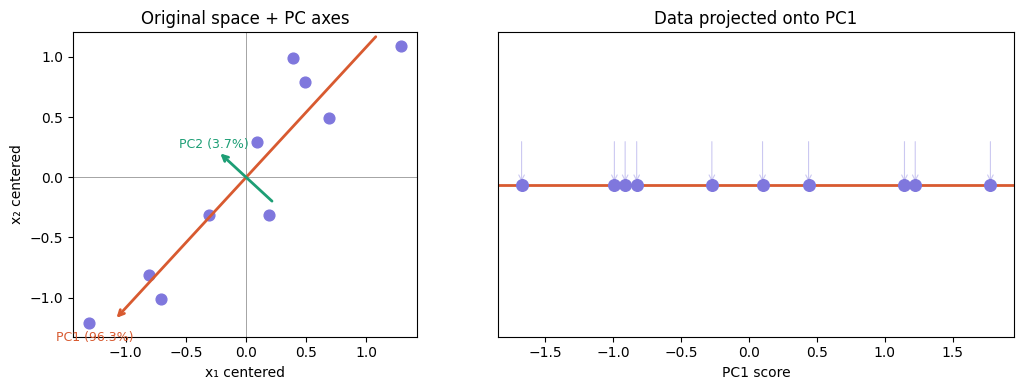

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data (same 10 points from the stepper) ──────────────────────────────────
X = np.array([
    [2.5, 2.4], [0.5, 0.7], [2.2, 2.9], [1.9, 2.2], [3.1, 3.0],
    [2.3, 2.7], [2.0, 1.6], [1.0, 1.1], [1.5, 1.6], [1.1, 0.9]
])

# ── Step 1: Center the data ──────────────────────────────────────────────────
mean = X.mean(axis=0)          # [1.81, 1.91]
X_c  = X - mean                # subtract mean from every row

# ── Step 2: Covariance matrix ────────────────────────────────────────────────
C = (X_c.T @ X_c) / len(X)
# C = [[0.616, 0.615],
#      [0.615, 0.717]]

# ── Step 3: Eigendecomposition  C·v = λ·v ───────────────────────────────────
eigenvalues, eigenvectors = np.linalg.eig(C)
# eigenvalues  = [1.284, 0.049]
# eigenvectors = columns → each column is one eigenvector

# ── Step 4: Sort by eigenvalue (largest first) ───────────────────────────────
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]   # shape (2, 2) — columns are PC axes

explained_variance = eigenvalues / eigenvalues.sum()
# [0.963, 0.037] → PC1 captures 96.3 %

# ── Step 5: Project onto principal components ────────────────────────────────
Z = X_c @ eigenvectors          # shape (10, 2) — full projection
Z_1d = X_c @ eigenvectors[:, 0] # shape (10,)  — keep only PC1 (96.3 % info)

# ── Results ──────────────────────────────────────────────────────────────────
print("Mean:              ", mean.round(3))
print("Covariance matrix:\n", C.round(3))
print("Eigenvalues:       ", eigenvalues.round(3))
print("Eigenvectors (cols):\n", eigenvectors.round(3))
print("Explained variance:", (explained_variance * 100).round(1), "%")
print("PC1 scores:        ", Z_1d.round(3))
# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: original space with PC axes overlaid
ax = axes[0]
ax.scatter(X_c[:, 0], X_c[:, 1], color='#7F77DD', zorder=3, s=60)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
for i, (val, vec, col, label) in enumerate(zip(
    eigenvalues, eigenvectors.T,
    ['#D85A30', '#1D9E75'],
    ['PC1 (96.3%)', 'PC2 (3.7%)']
)):
    scale = np.sqrt(val) * 1.5
    ax.annotate('', xy=vec * scale, xytext=-vec * scale,
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(*(vec * scale * 1.15), label, color=col, fontsize=9, ha='center')
ax.set_title('Original space + PC axes'); ax.set_aspect('equal')
ax.set_xlabel('x₁ centered'); ax.set_ylabel('x₂ centered')

# Right: projected onto PC1 (1D)
ax2 = axes[1]
ax2.scatter(Z_1d, np.zeros_like(Z_1d), color='#7F77DD', s=70, zorder=3)
ax2.axhline(0, color='#D85A30', lw=2)
ax2.set_ylim(-0.5, 0.5); ax2.set_yticks([])
ax2.set_xlabel('PC1 score'); ax2.set_title('Data projected onto PC1')
for s in Z_1d:
    ax2.annotate('', xy=(s, 0), xytext=(s, 0.15),
                 arrowprops=dict(
    arrowstyle='->',
    color=(127/255, 119/255, 221/255, 0.4),
    lw=0.8
))

plt.tight_layout()
plt.savefig('pca_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
Z   = pca.fit_transform(X)          # centers automatically

print("Explained variance:", pca.explained_variance_ratio_.round(3))
print("Components (eigenvectors):\n", pca.components_.round(3))
print("Eigenvalues:", pca.explained_variance_.round(3))

# Keep only PC1
pca_1d = PCA(n_components=1)
Z_1d   = pca_1d.fit_transform(X)    # shape (10, 1)

Explained variance: [0.963 0.037]
Components (eigenvectors):
 [[ 0.678  0.735]
 [ 0.735 -0.678]]
Eigenvalues: [1.284 0.049]
